#Loading Libraries

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
import numpy as np
import subprocess
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, f1_score, balanced_accuracy_score, recall_score
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
#from sklearn.feature_extraction.text import CountVectorizer  #DT does not take strings as input for the model fit step....
from IPython.display import Image
#import pydotplus as pydot
from sklearn import tree
warnings.filterwarnings('ignore')
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# **Date Cleaning and Loading**

**cleaning and doing one hot encoding**

In [5]:
url = 'https://raw.githubusercontent.com/finsaccount/Intrusion-Detection-System-Machine-Learning/refs/heads/main/data%202.csv'
data = pd.read_csv(url)
labels_dict={'attack':1, 'benign':0}
data['label2'] = data['label2'].map(labels_dict)
data = data.dropna()
data = data.drop('label', axis=1)
data.head()


,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_fragmented-packets,network_fragmentation-score,...,network_packets_dst_count,network_interval-packets,log_messages_count,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,timeDurationInSeconds,label2
0,63.000000,64.0,62.0,1.000017,20.0,20.0,20.0,0.0,0,0,...,14750,3108.335228,29500,0,0,0,0,0,10,1
1,62.999877,64.0,61.0,1.000246,20.0,20.0,20.0,0.0,0,0,...,4065,914.745196,8133,0,0,0,0,0,10,1
2,62.675676,64.0,62.0,0.949158,20.0,20.0,20.0,0.0,0,0,...,98,30.766254,148,0,0,0,0,0,10,1
3,63.000000,64.0,62.0,1.000023,20.0,20.0,20.0,0.0,0,0,...,11080,2500.940731,22160,0,0,0,0,0,10,1
5,62.857143,64.0,62.0,1.069045,20.0,20.0,20.0,0.0,0,0,...,4,0.707193,7,0,0,0,0,0,10,1


In [6]:
X = data.drop('label2', axis=1)
Y = data.pop('label2')
x_train, x_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size=0.3,
                                                    random_state=123,
                                                    shuffle=True)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

## Individual Model

**Support Vector Machine**

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       214
           1       0.99      0.97      0.98       278

    accuracy                           0.98       492
   macro avg       0.98      0.98      0.98       492
weighted avg       0.98      0.98      0.98       492

Precision 0.9676258992805755
F1 0.9799635701275046
Recall 0.992619926199262
Balanced Accuracy 0.9759479721494048


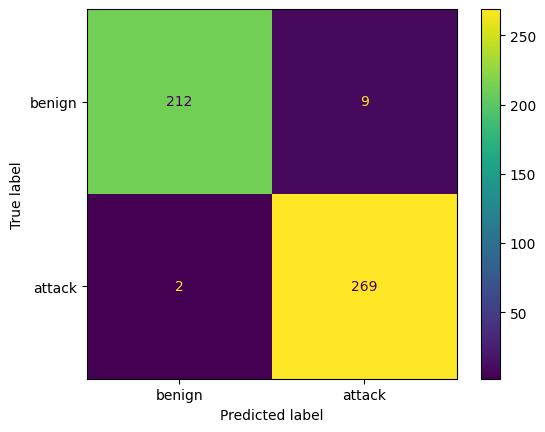

In [46]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', C=100, gamma = 0.01)
svm_model.fit(x_train_scaled, y_train)
predictionSVM = svm_model.predict(x_test_scaled)
cm = confusion_matrix(y_test, predictionSVM, labels=y_test.unique())
print(classification_report(predictionSVM, y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
print(f"Precision {precision_score(y_test, predictionSVM)}")
print(f"F1 {f1_score(y_test, predictionSVM)}")
print(f"Recall {recall_score(y_test, predictionSVM)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictionSVM)}")

**KNN**

In [30]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier()

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       210
           1       0.98      0.94      0.96       282

    accuracy                           0.95       492
   macro avg       0.95      0.96      0.95       492
weighted avg       0.95      0.95      0.95       492

Precision 0.9397163120567376
F1 0.9584086799276673
Recall 0.977859778597786
Balanced Accuracy 0.9504683508373546


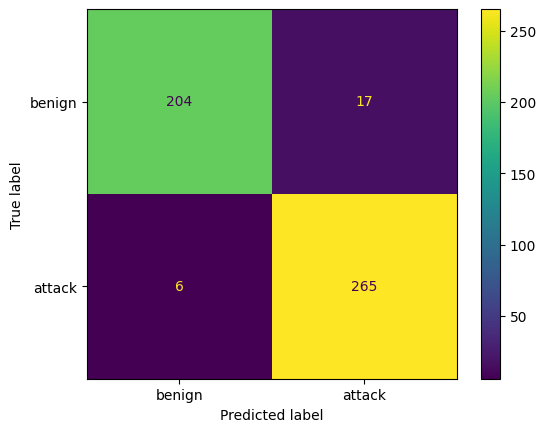

In [44]:
predictionKNN = knn_model.predict(x_test_scaled)
cm = confusion_matrix(y_test, predictionKNN, labels=y_test.unique())
print(classification_report(predictionKNN, y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
print(f"Precision {precision_score(y_test, predictionKNN)}")
print(f"F1 {f1_score(y_test, predictionKNN)}")
print(f"Recall {recall_score(y_test, predictionKNN)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictionKNN)}")

**Random Forest**

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       221
           1       0.99      0.99      0.99       271

    accuracy                           0.99       492
   macro avg       0.99      0.99      0.99       492
weighted avg       0.99      0.99      0.99       492

Precision 0.988929889298893
F1 0.988929889298893
Recall 0.988929889298893
Balanced Accuracy 0.9876776143327044


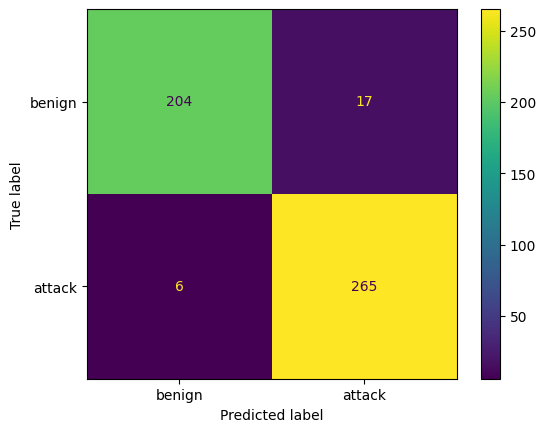

In [45]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
predictionTree = rf_model.predict(x_test)
print(classification_report(predictionTree, y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()
print(f"Precision {precision_score(y_test, predictionTree)}")
print(f"F1 {f1_score(y_test, predictionTree)}")
print(f"Recall {recall_score(y_test, predictionTree)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictionTree)}")

In [22]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import pydot
from IPython.display import Image


rf_model.fit(x_train, y_train)
individual_tree = rf_model.estimators_[0]

export_graphviz(individual_tree, out_file='raw.dot',
                feature_names=list(x_train),
                class_names=label_names,
                rounded=True, filled=True)
(graph,) = pydot.graph_from_dot_file('raw.dot')
graph.write_png('individual_tree.png')
# plt.figure(figsize=(12,8))
# plot_tree(individual_tree, feature_names= list(x_train),class_names=label_names, filled=True)

# Voting Classifier

Classification Report for Voting SOFT
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       221
           1       0.96      0.99      0.98       271

    accuracy                           0.98       492
   macro avg       0.98      0.97      0.98       492
weighted avg       0.98      0.98      0.98       492

Precision 0.96415770609319
F1 0.9781818181818182
Recall 0.992619926199262
Balanced Accuracy 0.9736855287104907


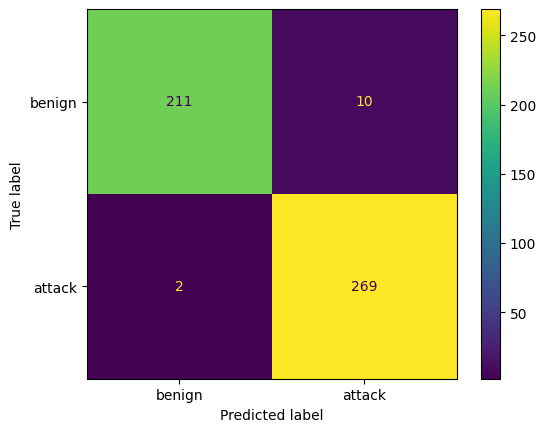

In [48]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

svm_model = SVC(kernel='rbf', C=100, gamma=0.01, probability=True)
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
voting_clf = VotingClassifier(
    estimators=[('svm', svm_model), ('knn', knn_model), ('rf', rf_model)],
    voting='soft'
)
voting_clf.fit(x_train_scaled, y_train)
predictions = voting_clf.predict(x_test_scaled)
print("Classification Report for Voting SOFT")
print(classification_report(y_test, predictions))
print(f"Precision {precision_score(y_test, predictions)}")
print(f"F1 {f1_score(y_test, predictions)}")
print(f"Recall {recall_score(y_test, predictions)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictions)}")
cm = confusion_matrix(y_test, predictions, labels=y_test.unique())
label_names = [name for name, val in sorted(labels_dict.items(), key=lambda item: item[1])]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot();

Classification Report for Voting HARD
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       221
           1       0.96      0.99      0.98       271

    accuracy                           0.98       492
   macro avg       0.98      0.97      0.98       492
weighted avg       0.98      0.98      0.98       492

Precision 0.96415770609319
F1 0.9781818181818182
Recall 0.992619926199262
Balanced Accuracy 0.9736855287104907


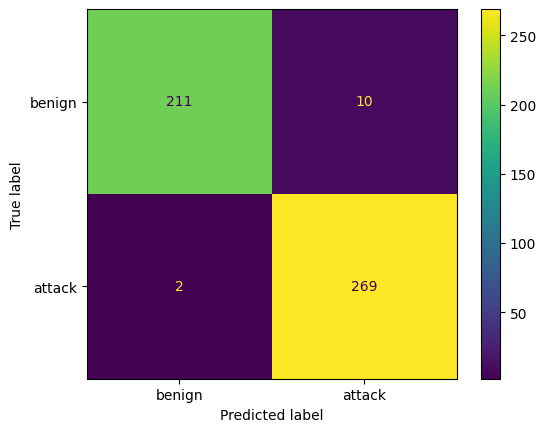

In [49]:
svm_model = SVC(kernel='rbf', C=100, gamma=0.01, probability=True)
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
voting_clf = VotingClassifier(
    estimators=[('svm', svm_model), ('knn', knn_model), ('rf', rf_model)],
    voting='hard'
)
voting_clf.fit(x_train_scaled, y_train)
predictions = voting_clf.predict(x_test_scaled)
print("Classification Report for Voting HARD")
print(classification_report(y_test, predictions))
print(f"Precision {precision_score(y_test, predictions)}")
print(f"F1 {f1_score(y_test, predictions)}")
print(f"Recall {recall_score(y_test, predictions)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictions)}")
cm = confusion_matrix(y_test, predictions, labels=y_test.unique())
label_names = [name for name, val in sorted(labels_dict.items(), key=lambda item: item[1])]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot();

# Stacking Classifier

In [40]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

estimators = [
    ('svm', make_pipeline(StandardScaler(), SVC(kernel='rbf', C=100, gamma=0.01, probability=True))),
    ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))),
    ('rf', RandomForestClassifier(n_estimators=100))
]
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stack_clf.fit(x_train_scaled,y_train)

StackingClassifier(cv=5,
                   estimators=[('svm',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('svc',
                                                 SVC(C=100, gamma=0.01,
                                                     probability=True))])),
                               ('knn',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('kneighborsclassifier',
                                                 KNeighborsClassifier())])),
                               ('rf', RandomForestClassifier())],
                   final_estimator=LogisticRegression())

Classification Report for Stacking Ensemble
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       221
           1       0.96      0.99      0.98       271

    accuracy                           0.98       492
   macro avg       0.98      0.97      0.98       492
weighted avg       0.98      0.98      0.98       492

Precision 0.96415770609319
F1 0.9781818181818182
Recall 0.992619926199262
Balanced Accuracy 0.9736855287104907


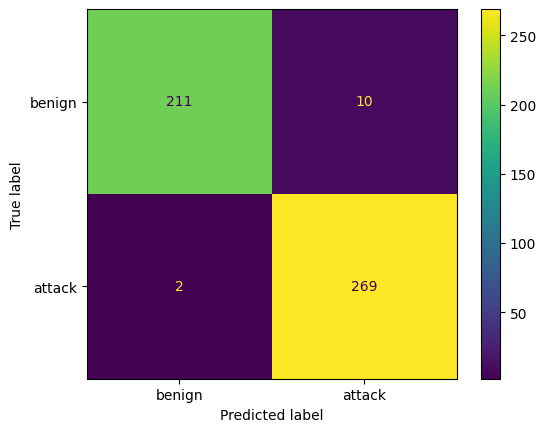

In [51]:
predictionsStack = stack_clf.predict(x_test_scaled)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Classification Report for Stacking Ensemble")
print(classification_report(y_test, predictionsStack))
print(f"Precision {precision_score(y_test, predictionsStack)}")
print(f"F1 {f1_score(y_test, predictionsStack)}")
print(f"Recall {recall_score(y_test, predictionsStack)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictionsStack)}")

#  'attack': 1, 'benign': 0
label_names = [name for name, val in sorted(labels_dict.items(), key=lambda item: item[1])]

cm = confusion_matrix(y_test, predictionsStack, labels=y_test.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()


# Bagging Classifier

In [ ]:
from sklearn.ensemble import BaggingClassifier
bag_dt = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag_dt.fit(x_train,y_train)
print(classification_report(y_test, bag_dt.predict(x_test)))

In [ ]:
bag_knn = BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=5), n_estimators=50)
bag_knn.fit(x_train, y_train)
print(classification_report(y_test, bag_knn.predict(x_test)))

In [ ]:
bag_svm = BaggingClassifier(estimator=SVC(), n_estimators=10)
bag_svm.fit(x_train, y_train)
print(classification_report(y_test, bag_knn.predict(x_test)))

# Summary

The Stacking Classifier worked best.
It produced a model with an accuracy of 98%